# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

#Retain original class names without one-hot encoding
y_train_og = y_train 
X_test_og = X_test 

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10) #10 because there are 10 classes in class_names
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


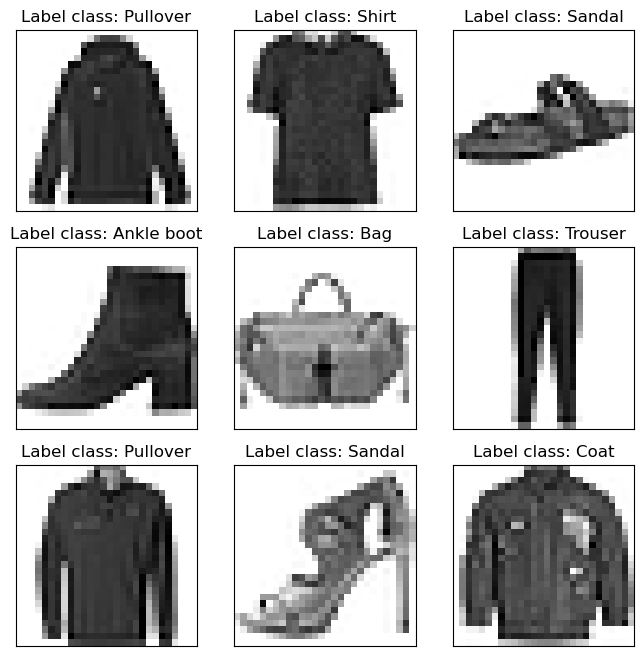

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected

# Selecting 9 random indices
random_indices = np.random.choice(len(y_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label class: {class_names[y_train_og[random_indices[i]]]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

The data looks as expected, though it's low resolution (28x28 pixels). The y values already being numerical (e.g., 1, 2, 3, etc.) instead of "T-shirt/top", "Trouser", etc. did need to be converted to be easily understood in the view above, which required retaining the original y values without one-hot encoding and then choosing the relevant index from `class names`. 

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()

# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation for multi-class function 

model.summary() #The output should show one flattening layer and one dense layer, creating an SLR model

# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=36, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


2025-10-26 23:22:24.237785: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.6311 - loss: 1.1769 - val_accuracy: 0.7858 - val_loss: 0.6713
Epoch 2/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7949 - loss: 0.6475 - val_accuracy: 0.8053 - val_loss: 0.5914
Epoch 3/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8133 - loss: 0.5807 - val_accuracy: 0.8106 - val_loss: 0.5573
Epoch 4/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8189 - loss: 0.5560 - val_accuracy: 0.8194 - val_loss: 0.5352
Epoch 5/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8291 - loss: 0.5222 - val_accuracy: 0.8263 - val_loss: 0.5158
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8203 - loss: 0.5321
Loss:     0.54
Accuracy: 81.55%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The performance of the baseline model is 81.55% accuracy. Which is around what I would have expected given the low-resolution of the images resulting a more complex examples than hand-written numbers which only correspond to their specific class (1=1, 2=2, etc.). These examples, however, provide more dynamic images to assign to the same number of classes (10 classes) for dress vs coat, or sandal vs sneaker, etc. 

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [35]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1))) #Convolutional layer to learn spatial hierarchies
model.add(Flatten()) # Flatten layer to put into the connected layers
model.add(Dense(10, activation='softmax')) #Fully connected layer with 10 neurons, softmax activation as the output layer

model.summary()

#Train the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=36, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

#Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │       184,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,162 (723.29 KB)

 Trainable params: 185,162 (723.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


2025-10-27 00:34:24.066848: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.6750 - loss: 0.9559 - val_accuracy: 0.7958 - val_loss: 0.5581
Epoch 2/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8197 - loss: 0.5109 - val_accuracy: 0.8011 - val_loss: 0.5348
Epoch 3/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8422 - loss: 0.4591 - val_accuracy: 0.8250 - val_loss: 0.4856
Epoch 4/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8521 - loss: 0.4277 - val_accuracy: 0.8561 - val_loss: 0.4141
Epoch 5/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8592 - loss: 0.4044 - val_accuracy: 0.8374 - val_loss: 0.4343
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8325 - loss: 0.4571
Loss:     0.45
Accuracy: 83.14%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

I tested this model with a regular sgd optimizer and the adam optimizer. 

SGD: 

The CNN model performed slightly better than the baseline model, ending with a ~0.3% better accuracy and reduced accuracy loss from 0.53 down to 0.46. This is due to the specialization of convolutional layers to analyze and learn from visual images, which is our source data in this case. The convolution layer is able to assess spatial hierarchy information in an image via a grid-search--the kernel size--to find visual attributes (e.g., the edges of a dress vs a coat, or buttons on a shirt vs t-shirt, etc.) which are more effective than a 1-dimensional array for images vs a traditional CNN model.  

Adam:

The CNN model performed substantially better than the baseline model, its Epoch 1 starting accuracy being almost as high as the baseline model's Epoch 5 accuracy and a finishing accuracy of just over 10 percentage points higher (~93%). The Adam optimizer uses different learning rates for different parameters, allowing it to more consistently *and* more rapidly achieve higher predictive accuracy. 

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [48]:
import pandas as pd

# A. Test Hyperparameters - using Filters, as I don't think changing the kernel size wil offer a major benefit given the image size

filters = [16, 64, 128]
res_acc = []
res_loss = []

for i in range(3):
    print(f'Hyperparameter Modification #{i+1} | Conv2D Filters = {filters[i]}: ')
    model = Sequential()
    model.add(Conv2D(filters=filters[i], kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1))) #Convolutional layer to learn spatial hierarchies
    model.add(Flatten()) # Flatten layer to put into the connected layers
    model.add(Dense(10, activation='softmax')) #Fully connected layer with 10 neurons, softmax activation as the output layer
    #model.summary()
    #Train the model
    model.compile(
        loss='categorical_crossentropy',
        optimizer='sgd',
        metrics=['accuracy']
    )
    model.fit(
        X_train, # Training data
        y_train, # Training labels
        epochs=5, # Number of epochs
        batch_size=36, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )
    #Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f'Loss:     {loss:.2f}')
    print(f'Accuracy: {accuracy*100:.2f}%')
    res_loss.append(loss)
    res_acc.append(accuracy)


results_df = pd.DataFrame({
    'Filters': filters,
    'Test_Loss': res_loss,
    'Test_Accuracy': res_acc
})

print(results_df)

Hyperparameter Modification #1 | Conv2D Filters = 16: 
Epoch 1/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6782 - loss: 0.9646 - val_accuracy: 0.7952 - val_loss: 0.6591
Epoch 2/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8136 - loss: 0.5236 - val_accuracy: 0.8178 - val_loss: 0.5319
Epoch 3/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8398 - loss: 0.4689 - val_accuracy: 0.8338 - val_loss: 0.4621
Epoch 4/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.8497 - loss: 0.4348 - val_accuracy: 0.8098 - val_loss: 0.5172
Epoch 5/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8590 - loss: 0.4093 - val_accuracy: 0.8600 - val_loss: 0.4015
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8563 - loss: 0.4176
Loss:     0.42
Accuracy: 85.15%
Hyperparameter Modification #2 | Conv2D Filters = 64: 
Epoch 1/5


2025-10-27 01:49:13.502446: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.6803 - loss: 0.9388 - val_accuracy: 0.8127 - val_loss: 0.5374
Epoch 2/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.8170 - loss: 0.5197 - val_accuracy: 0.8069 - val_loss: 0.5405
Epoch 3/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.8416 - loss: 0.4601 - val_accuracy: 0.8459 - val_loss: 0.4404
Epoch 4/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.8526 - loss: 0.4252 - val_accuracy: 0.8546 - val_loss: 0.4222
Epoch 5/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.8626 - loss: 0.4016 - val_accuracy: 0.8613 - val_loss: 0.4017
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8560 - loss: 0.4184
Loss:     0.42
Accuracy: 85.35%
Hyperparameter Modification #3 | Conv2D Filters = 128: 
Epoch 1/5


2025-10-27 01:51:13.881032: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.6830 - loss: 0.9481 - val_accuracy: 0.8011 - val_loss: 0.5746
Epoch 2/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.8191 - loss: 0.5155 - val_accuracy: 0.8336 - val_loss: 0.4791
Epoch 3/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.8434 - loss: 0.4471 - val_accuracy: 0.8410 - val_loss: 0.4529
Epoch 4/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.8535 - loss: 0.4207 - val_accuracy: 0.8522 - val_loss: 0.4232
Epoch 5/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.8618 - loss: 0.4008 - val_accuracy: 0.8473 - val_loss: 0.4339
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8485 - loss: 0.4443
Loss:     0.45
Accuracy: 84.35%
   Filters  Test_Loss  Test_Accuracy
0       16   0.422161         0.8515
1       64   0.422295         0.8535
2      128   0.454575         0.8435


In [51]:
# B. Test presence or absence of regularization
from keras.layers import Dropout

filters = [64, 128]
res_acc = []
res_loss = []

for i in range(2):
    model = Sequential()

    print(f'Regularization Modification | Dropout Layer with Conv2D Filters = 64: ')

    model.add(Conv2D(filters=128, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1))) #Convolutional layer to learn spatial hierarchies
    model.add(Flatten()) # Flatten layer to put into the connected layers
    model.add(Dropout(0.1)) #Adding a dropout layer after the layer with the highest number of parameters to reduce potential over-fitting 
    model.add(Dense(10, activation='softmax')) #Fully connected layer with 10 neurons, softmax activation as the output layer

    model.summary()

    #Train the model
    model.compile(
        loss='categorical_crossentropy',
        optimizer='sgd',
        metrics=['accuracy']
    )

    model.fit(
        X_train, # Training data
        y_train, # Training labels
        epochs=5, # Number of epochs
        batch_size=36, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )

    #Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f'Loss:     {loss:.2f}')
    print(f'Accuracy: {accuracy*100:.2f}%')
    res_loss.append(loss)
    res_acc.append(accuracy)

results_df = pd.DataFrame({
    'Filters': filters,
    'Test_Loss': res_loss,
    'Test_Accuracy': res_acc
})

print(results_df)

Regularization Modification | Dropout Layer with Conv2D Filters = 64: 


Model: "sequential_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 24, 24, 128)    │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_43 (Flatten)            │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │       737,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,618 (2.83 MB)

 Trainable params: 740,618 (2.83 MB)

...

 Trainable params: 740,618 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


2025-10-27 02:09:27.113578: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.6895 - loss: 0.9349 - val_accuracy: 0.7989 - val_loss: 0.5662
Epoch 2/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.8189 - loss: 0.5179 - val_accuracy: 0.8328 - val_loss: 0.4827
Epoch 3/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.8387 - loss: 0.4645 - val_accuracy: 0.8390 - val_loss: 0.4503
Epoch 4/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.8537 - loss: 0.4238 - val_accuracy: 0.8541 - val_loss: 0.4204
Epoch 5/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.8618 - loss: 0.4099 - val_accuracy: 0.8659 - val_loss: 0.3870
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8632 - loss: 0.4027
Loss:     0.41
Accuracy: 85.69%
   Filters  Test_Loss  Test_Accuracy
0       64   0.432534         0.8444
1      128   0.408843         0.8569


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

Note: The regularization function was only run once because the lack of it was Hyperparamter Case #3 for comparison. 

For the Filters hyperparameter, increasing filters from 16 to 64 provided a marginal benefit in accuracy (0.2%) and loss (~0.00015), but not majorly so; however, going from 64 to 128 filters reduced the accuracy by almost 1%, indicating that this is too many filters for the complexity of the dataset.  

For regularization, adding a Dropout layer after the Flattening layer increased accuracy versus not having regularization by 0.05% (from 85.35% to 85.40%), and loss stayed consistent for 64 filters, but the best performing model was using the Dropout layer with 128 filters, leading to an accuracy of 85.69% and reduced loss to 0.41.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [53]:
model = Sequential()

print(f'Regularization Modification | Dropout Layer with Conv2D Filters = 64: ')
model.add(Conv2D(filters=128, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1))) #Convolutional layer to learn spatial hierarchies
model.add(Flatten()) # Flatten layer to put into the connected layers
model.add(Dropout(0.1)) #Adding a dropout layer after the layer with the highest number of parameters to reduce potential over-fitting 
model.add(Dense(10, activation='softmax')) #Fully connected layer with 10 neurons, softmax activation as the output layer

model.summary()

#Train the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
    )

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=36, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

#Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Regularization Modification | Dropout Layer with Conv2D Filters = 64: 


Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 24, 24, 128)    │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_46 (Flatten)            │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 10)             │       737,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,618 (2.83 MB)

 Trainable params: 740,618 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


2025-10-27 02:17:44.462527: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.6787 - loss: 0.9423 - val_accuracy: 0.8008 - val_loss: 0.5754
Epoch 2/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.8183 - loss: 0.5181 - val_accuracy: 0.8121 - val_loss: 0.5181
Epoch 3/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.8391 - loss: 0.4606 - val_accuracy: 0.8301 - val_loss: 0.4851
Epoch 4/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.8523 - loss: 0.4322 - val_accuracy: 0.8490 - val_loss: 0.4248
Epoch 5/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8621 - loss: 0.4027 - val_accuracy: 0.8612 - val_loss: 0.3997
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8565 - loss: 0.4138
Loss:     0.42
Accuracy: 85.31%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

The final model is moderately more accurate than the CNN method (~2%) and notably more accurate than SLR (~4%) while providing a smaller accuracy loss than both (-0.13 and -0.03). I believe the combination of training the model on more granular data (increased filters) *and* ignoring a set of neurons during training iterations via the Dropout set (~10% from the Flatten layer to the Dense layer) allowed the model to be more accurate without overfitting too drastically. 

If I had more time, I would like to experiment with optimization functions. As above, initial trials on the CNN using `adam` instead of `sgd` provided by far the most substantial accuracy increase (to ~93%) than tweaking hyperparameters and regularization layers. Using an appropriate optimization function can be equally as valuable as what we tweaked in the experiment, especially given constraints to the original sample size, such as image quality or sample amount.  

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.